In [4]:
!pip install matplotlib seaborn -q

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid",palette="muted")
plt.rcParams["figure.figsize"]=(10,5)

#load raw dataset

df=pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

print(f"Dataset Shape :{df.shape[0]} rows,{df.shape[1]} colums")
df.head(3)

Dataset Shape :7043 rows,21 colums


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [ ]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [16]:
# since total charges is str
# finding out any missing vallue in TotalCharges
blank_charges = df[df["TotalCharges"] == " "]
print(f"\nNumber of rows with whitespace in TotalCharges: {len(blank_charges)}")
print("Tenure for these customers:", blank_charges["tenure"].unique())


df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)
print("\nFixed TotalCharges dtype:",df["TotalCharges"].dtype)


Number of rows with whitespace in TotalCharges: 0
Tenure for these customers: []

Fixed TotalCharges dtype: float64


/tmp/ipykernel_33144/1432548153.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=axes[0], palette=["#2b5c8f", "#d9534f"])


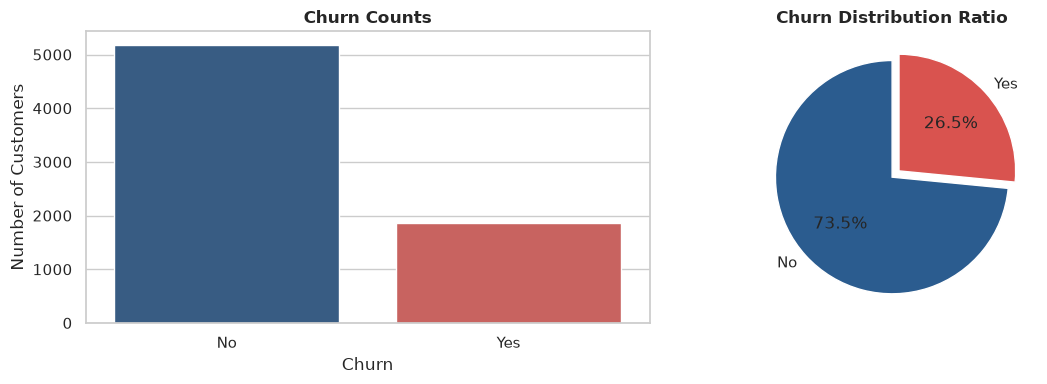

Overall Churn Rate: 26.54% | Retained Rate: 73.46%


In [17]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar Chart
sns.barplot(x=churn_counts.index, y=churn_counts.values, ax=axes[0], palette=["#2b5c8f", "#d9534f"])
axes[0].set_title("Churn Counts", fontsize=12, weight="bold")
axes[0].set_ylabel("Number of Customers")

# Pie Chart
axes[1].pie(churn_pct, labels=churn_pct.index, autopct="%1.1f%%", colors=["#2b5c8f", "#d9534f"], startangle=90, explode=(0, 0.08))
axes[1].set_title("Churn Distribution Ratio", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()

print(f"Overall Churn Rate: {churn_pct['Yes']:.2f}% | Retained Rate: {churn_pct['No']:.2f}%")


/tmp/ipykernel_33144/2194507671.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#2b5c8f", "#d9534f"], ax=axes[1])


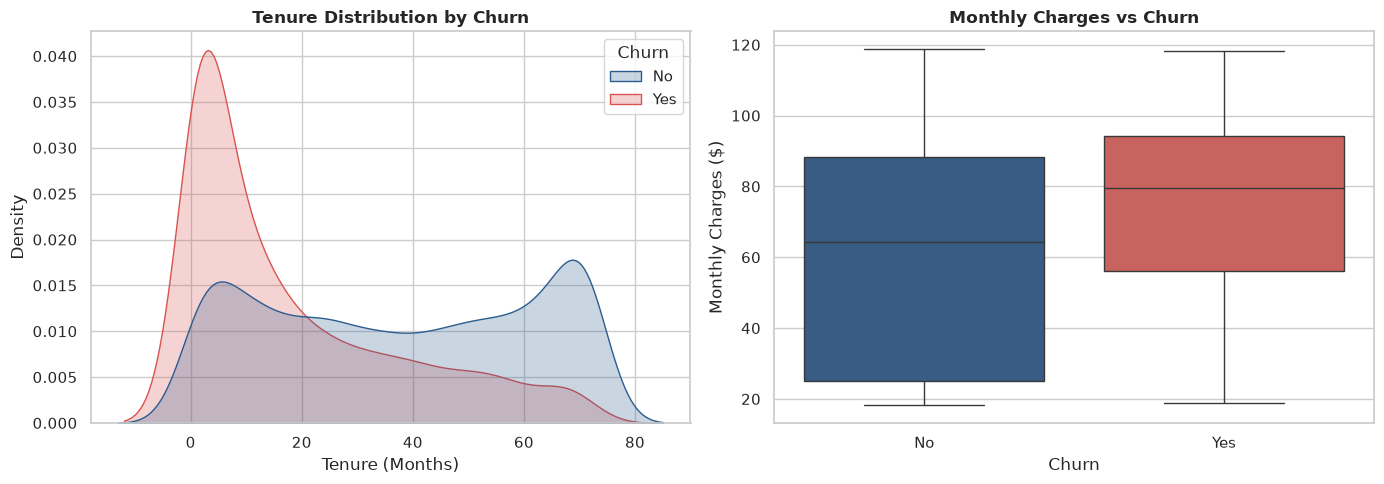

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tenure distribution by Churn
sns.kdeplot(data=df, x="tenure", hue="Churn", common_norm=False, fill=True, palette=["#2b5c8f", "#d9534f"], ax=axes[0])
axes[0].set_title("Tenure Distribution by Churn", fontsize=12, weight="bold")
axes[0].set_xlabel("Tenure (Months)")

# Monthly Charges boxplot
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#2b5c8f", "#d9534f"], ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn", fontsize=12, weight="bold")
axes[1].set_ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()


/tmp/ipykernel_33144/1530456603.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=contract_churn, x="Contract", y="Churn", palette="Reds_r")


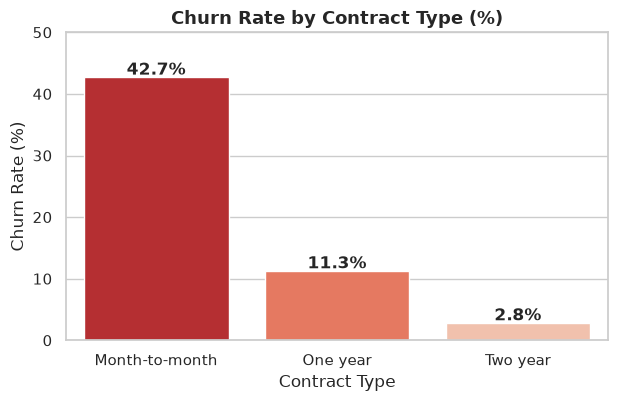

In [19]:
contract_churn = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).reset_index()

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=contract_churn, x="Contract", y="Churn", palette="Reds_r")
plt.title("Churn Rate by Contract Type (%)", fontsize=13, weight="bold")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', weight='bold')

plt.ylim(0, 50)
plt.show()


/tmp/ipykernel_33144/2879439171.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=net_churn, x="InternetService", y="Churn", ax=axes[0], palette="Blues_r")
/tmp/ipykernel_33144/2879439171.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pay_churn, x="PaymentMethod", y="Churn", ax=axes[1], palette="Purples_r")


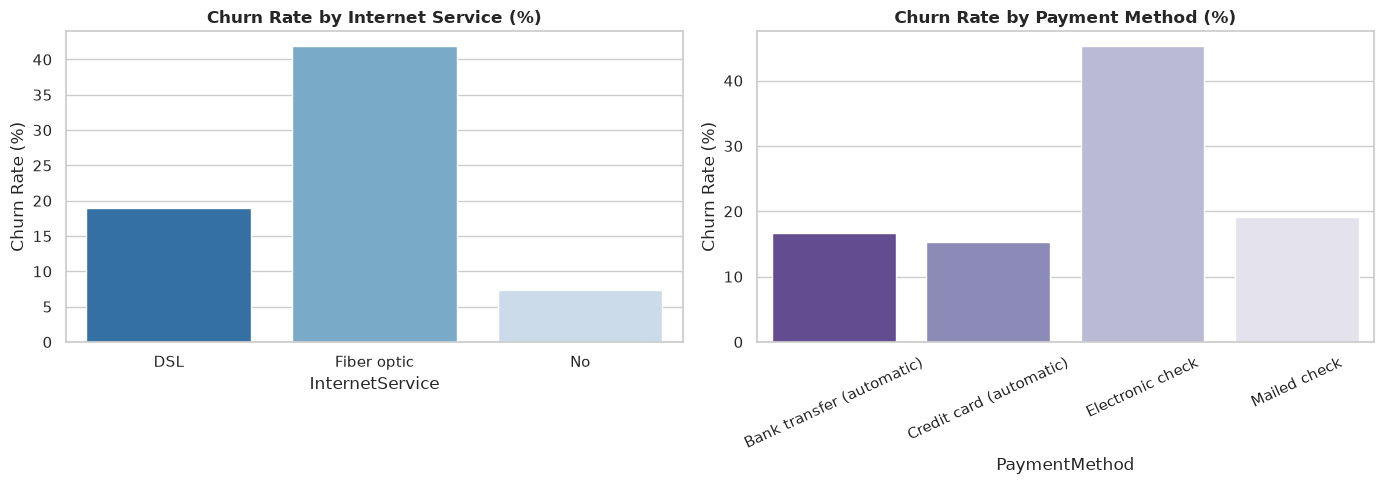

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn by Internet Service
net_churn = df.groupby("InternetService")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).reset_index()
sns.barplot(data=net_churn, x="InternetService", y="Churn", ax=axes[0], palette="Blues_r")
axes[0].set_title("Churn Rate by Internet Service (%)", fontsize=12, weight="bold")
axes[0].set_ylabel("Churn Rate (%)")

# Churn by Payment Method
pay_churn = df.groupby("PaymentMethod")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).reset_index()
sns.barplot(data=pay_churn, x="PaymentMethod", y="Churn", ax=axes[1], palette="Purples_r")
axes[1].set_title("Churn Rate by Payment Method (%)", fontsize=12, weight="bold")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


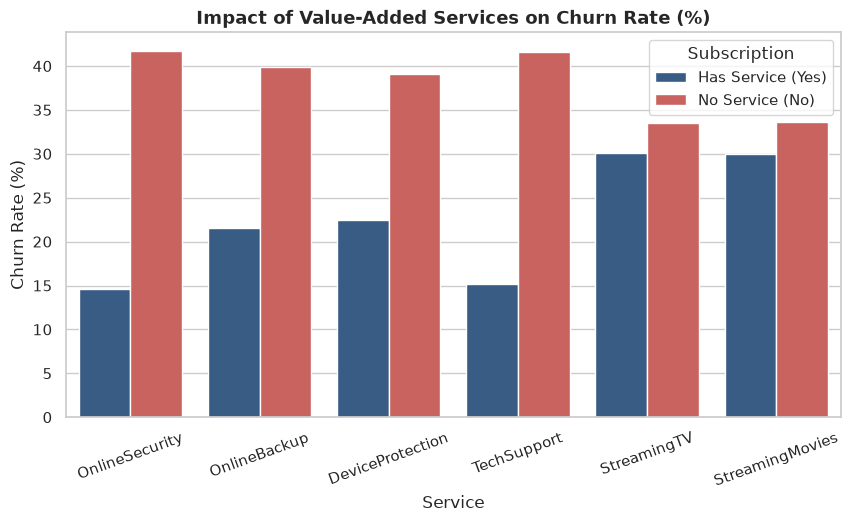

In [21]:
services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

service_churn_data = []
for service in services:
    rate = (df[df[service] == "Yes"]["Churn"] == "Yes").mean() * 100
    no_rate = (df[df[service] == "No"]["Churn"] == "Yes").mean() * 100
    service_churn_data.append({"Service": service, "Has Service (Yes)": rate, "No Service (No)": no_rate})

service_df = pd.DataFrame(service_churn_data).melt(id_vars="Service", var_name="Status", value_name="ChurnRate")

plt.figure(figsize=(10, 5))
sns.barplot(data=service_df, x="Service", y="ChurnRate", hue="Status", palette=["#2b5c8f", "#d9534f"])
plt.title("Impact of Value-Added Services on Churn Rate (%)", fontsize=13, weight="bold")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.legend(title="Subscription")
plt.show()
